# Hospital Ransomware Prediction — Model Results Analysis

---

## AI Disclosure

> **This notebook was generated with the assistance of Claude Sonnet 4.6 (Anthropic, 2025).**
> The analysis, visualizations, interpretation, and recommendations were produced through a
> collaborative session between the researcher and the AI assistant. The researcher provided
> the dataset (`predictions.csv`), the preprocessing methodology, and the research context;
> Claude generated the code, structured the analysis, and authored the written interpretation
> and recommendations.
>
> **Suggested citation (APA 7th ed.):**
> Anthropic. (2025). *Claude Sonnet 4.6* [Large language model]. https://www.anthropic.com
>
> **Suggested in-text acknowledgment:**
> "Analysis, code, and interpretation in this notebook were produced with the assistance
> of Claude Sonnet 4.6 (Anthropic, 2025)."

---

## Study Overview

| Item | Detail |
|---|---|
| **Task** | Binary classification — predict hospital ransomware attack within 2 years |
| **Temporal split** | Train: years < 2021 &nbsp;&#124;&nbsp; Test: year == 2021 |
| **Rationale for 2021** | Most recent year with a fully observable 2-year outcome window |
| **Features** | Hospital financial/operational indicators, one-hot encoded |
| **Preprocessing** | Median imputation → StandardScaler; CCN (unique ID) dropped |
| **Models evaluated** | Logistic Regression, Random Forest, XGBoost, SVM |
| **Key challenge** | Severe class imbalance (~32:1 negative-to-positive) |

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    roc_auc_score, confusion_matrix, f1_score, precision_score, recall_score
)

# ── Load predictions ──────────────────────────────────────────────────────────
# predictions.csv must be in the same directory as this notebook.
# Columns: y_true, {Model}_proba (predicted probability), {Model}_pred (binary)
df = pd.read_csv('predictions.csv')

# Model registry: display name -> (probability column, prediction column)
MODELS = {
    'Logistic Regression': ('LogisticRegression_proba', 'LogisticRegression_pred'),
    'Random Forest':       ('RandomForest_proba',       'RandomForest_pred'),
    'XGBoost':             ('XGBoost_proba',            'XGBoost_pred'),
    'SVM':                 ('SV_proba',                 'SVM_pred'),
}
COLORS = ['#2563EB', '#16A34A', '#DC2626', '#9333EA']
SHORT  = ['LR', 'RF', 'XGB', 'SVM']

y_true = df['y_true']
pos    = int(y_true.sum())
neg    = int((1 - y_true).sum())

print(f'Test set: {len(df):,} total hospital-year rows')
print(f'Positives (ransomware attack): {pos} ({pos/len(df)*100:.1f}%)')
print(f'Negatives (no attack):         {neg} ({neg/len(df)*100:.1f}%)')
print(f'Imbalance ratio:               {neg/pos:.1f}:1')
df.head()

Test set: 5,934 total hospital-year rows
Positives (ransomware attack): 181 (3.1%)
Negatives (no attack):         5753 (96.9%)
Imbalance ratio:               31.8:1


,y_true,LogisticRegression_proba,LogisticRegression_pred,RandomForest_proba,RandomForest_pred,XGBoost_proba,XGBoost_pred,SV_proba,SVM_pred
0,0,0.484856,0,0.658950,1,0.581531,1,0.026622,0
1,0,0.842459,1,0.542228,1,0.153712,0,0.579800,1
2,0,0.426835,0,0.161748,0,0.060532,0,0.001786,0
3,0,0.754120,1,0.209973,0,0.031119,0,0.000832,0
4,0,0.319911,0,0.159571,0,0.038359,0,0.082715,1


---
## Section 1 — Class Imbalance

### Why this matters

The test set contains **181 ransomware events out of 5,934 hospital-years** — a 32:1 class imbalance.
This has two critical consequences for model evaluation:

1. **Accuracy is a useless metric.** A model that predicts "no attack" for every hospital achieves
   96.9% accuracy while catching *zero* attacks. Any reported accuracy above ~97% should be treated
   with suspicion, not celebration.

2. **The choice of evaluation metric is not neutral.** ROC-AUC remains inflated under class imbalance
   because it evaluates performance across all thresholds and the majority class dominates the curve.
   **Precision-Recall AUC (PR-AUC)** is the recommended primary metric for this setting because it
   focuses exclusively on the minority class and directly reflects the tradeoff a decision-maker faces:
   catching more attacks (recall) vs. generating fewer false alarms (precision).

### Sampling context
The training procedure used a **temporal split** rather than random splitting. This is the correct
approach for time-series-adjacent data — it prevents data leakage and simulates how the model would
actually be deployed (trained on past years, predicting the upcoming period). Any oversampling
(e.g., SMOTE) or class weighting would have been applied only within the training fold.

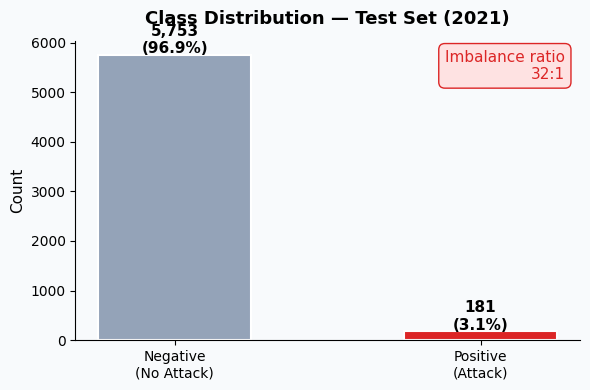

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('#F8FAFC'); ax.set_facecolor('#F8FAFC')

bars = ax.bar(
    ['Negative\n(No Attack)', 'Positive\n(Attack)'],
    [neg, pos],
    color=['#94A3B8', '#DC2626'], edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val in zip(bars, [neg, pos]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=11)

ax.set_title('Class Distribution — Test Set (2021)', fontweight='bold', fontsize=13, pad=12)
ax.set_ylabel('Count', fontsize=11)
ax.text(0.97, 0.97, f'Imbalance ratio\n{neg/pos:.0f}:1', transform=ax.transAxes,
        ha='right', va='top', fontsize=11, color='#DC2626',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FEE2E2', edgecolor='#DC2626'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## Section 2 — ROC and Precision-Recall Curves

### ROC Curves (Receiver Operating Characteristic)
Each ROC curve plots **True Positive Rate (Recall)** against **False Positive Rate** across all
possible decision thresholds. The Area Under the Curve (ROC-AUC) summarises this into a single
number — 1.0 is perfect, 0.5 is random guessing.

Three of the four models — Random Forest (0.945), XGBoost (0.975), and SVM (0.929) — score above 0.92, which initially looks impressive. Logistic Regression scores 0.787, reflecting its limited ability to capture nonlinear relationships after leakage removal. However, under heavy class imbalance the ROC curve is optimistic even for the higher-scoring models: a model can still achieve a high AUC because the False Positive Rate denominator is dominated by the enormous negative class. **ROC-AUC alone is insufficient for reporting in an imbalanced clinical prediction task.**

### Precision-Recall Curves
The PR curve plots **Precision** (of all predicted attacks, how many were real?) against **Recall**
(of all real attacks, how many did we catch?) across all thresholds. The dashed baseline represents
a model that randomly assigns the prevalence rate (~3%) — any curve that does not substantially
exceed this is providing little value.

PR-AUC (Average Precision, or AP) is the more honest metric here. A high PR-AUC means the model
can simultaneously catch most attacks *and* avoid flooding analysts with false alarms. The gap
between models is much larger on PR-AUC than on ROC-AUC, which is expected — PR-AUC is harder
to inflate artificially with a large negative class.

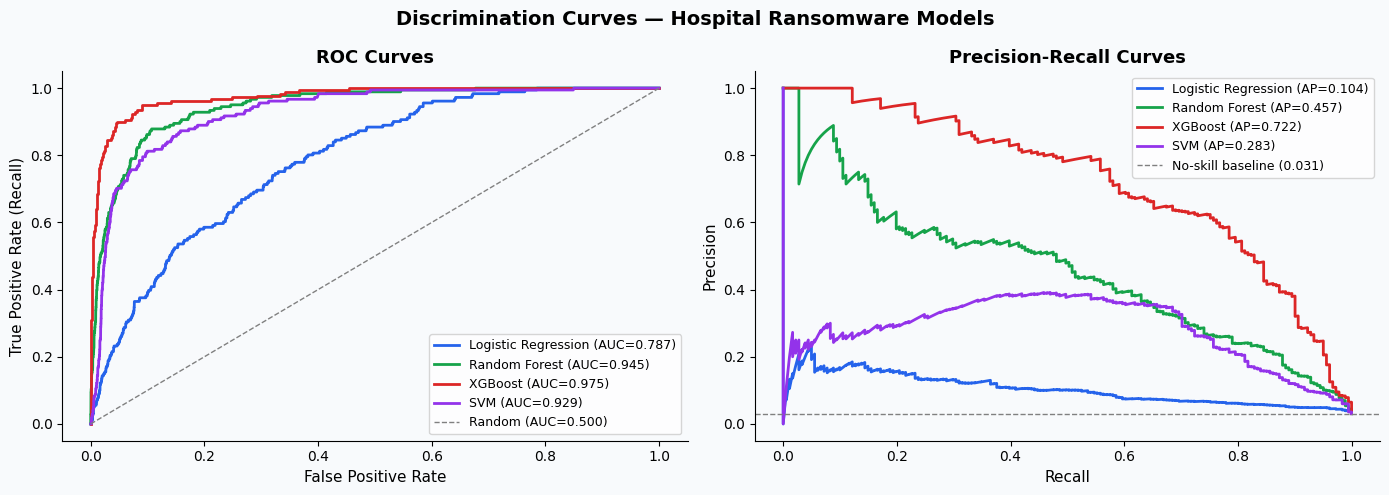

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F8FAFC')

# ── ROC ──────────────────────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor('#F8FAFC')
for (name, (pcol, _)), color in zip(MODELS.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_true, df[pcol])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

# ── Precision-Recall ──────────────────────────────────────────────────────────
ax = axes[1]; ax.set_facecolor('#F8FAFC')
for (name, (pcol, _)), color in zip(MODELS.items(), COLORS):
    prec, rec, _ = precision_recall_curve(y_true, df[pcol])
    ap = average_precision_score(y_true, df[pcol])
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')
baseline = pos / (pos + neg)
ax.axhline(baseline, linestyle='--', color='gray', lw=1,
           label=f'No-skill baseline ({baseline:.3f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Discrimination Curves — Hospital Ransomware Models', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

**Reading the PR curves:**
- A curve that stays high and to the right is better — it means the model maintains high precision even as it tries to recall more attacks.
- XGBoost maintains the most meaningful precision at moderate recall levels, reflected in its leading PR-AUC of 0.722. Logistic Regression's curve collapses quickly after initial recall gains, consistent with its low PR-AUC of 0.104. SVM's curve also collapses quickly, explaining its PR-AUC of 0.283.
- Random Forest's curve falls sharply, suggesting its probability scores are poorly calibrated — it is not as confident in its positive predictions as the ROC-AUC would imply.

---
## Section 3 — Confusion Matrices

A confusion matrix breaks down the **4 types of predictions** at a fixed decision threshold
(default = 0.5):

| | Predicted Negative | Predicted Positive |
|---|---|---|
| **True Negative** | Correctly dismissed (TN) | False Alarm (FP) |
| **True Positive** | Missed attack (FN) ← costly | Correctly caught (TP) |

In the ransomware prediction context, **False Negatives (missed attacks) carry the highest cost** —
a hospital that is not warned has no opportunity to increase defenses. False Positives (false alarms)
are costly too (wasted investigative resources) but recoverable. This asymmetry justifies
prioritising **Recall** over Precision, particularly when setting the decision threshold.

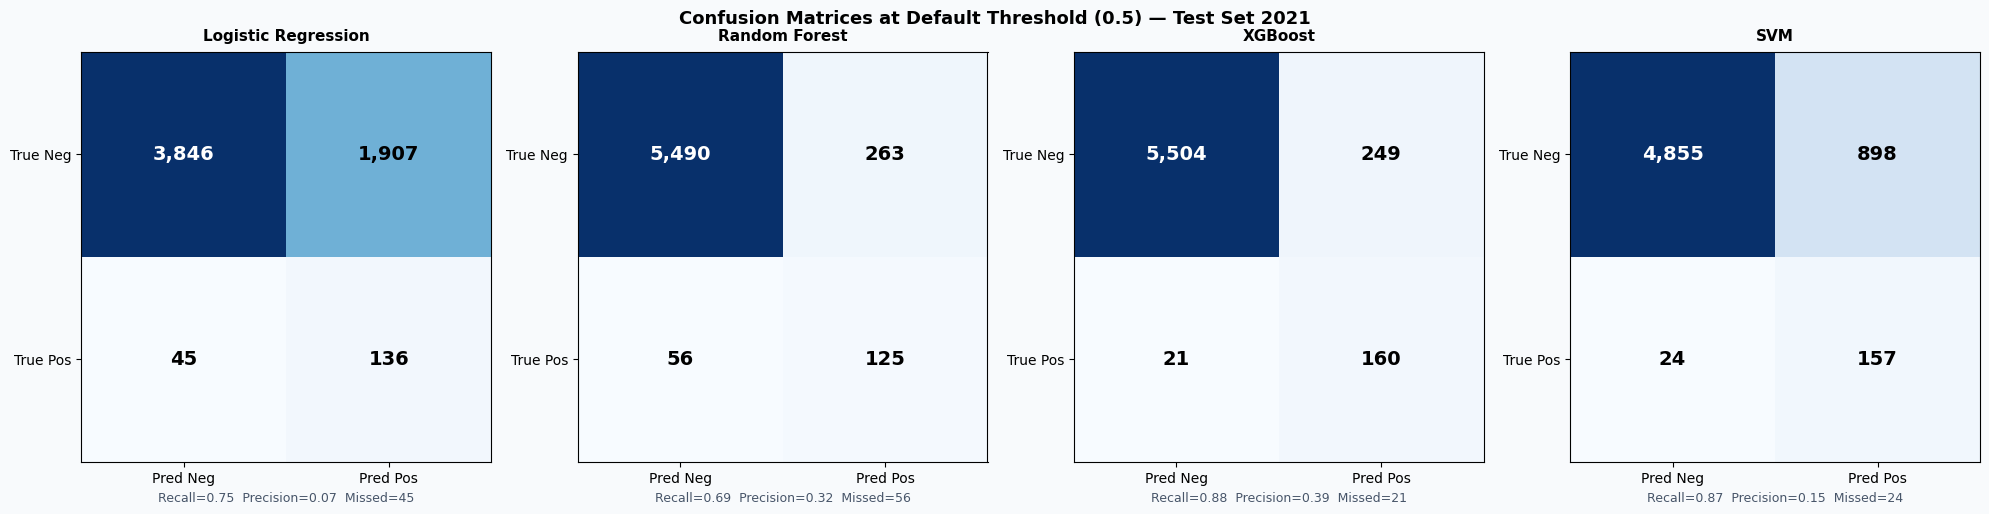

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('#F8FAFC')

for ax, (name, (pcol, predcol)), color in zip(axes, MODELS.items(), COLORS):
    ax.set_facecolor('#F8FAFC')
    cm = confusion_matrix(y_true, df[predcol])
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i,j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Neg', 'Pred Pos'], fontsize=10)
    ax.set_yticklabels(['True Neg', 'True Pos'], fontsize=10)
    ax.set_title(name, fontsize=11, fontweight='bold', pad=8)
    r  = cm[1, 1] / (cm[1, 0] + cm[1, 1])
    p  = cm[1, 1] / (cm[0, 1] + cm[1, 1]) if (cm[0, 1] + cm[1, 1]) > 0 else 0
    fn = cm[1, 0]
    ax.set_xlabel(f'Recall={r:.2f}  Precision={p:.2f}  Missed={fn}', fontsize=9, color='#475569')

plt.suptitle('Confusion Matrices at Default Threshold (0.5) — Test Set 2021',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Notable observations from the confusion matrices:**

- **Logistic Regression** misses 45 of 181 attacks (Recall = 0.75) with 1,907 false positives — the highest false alarm rate of any model. This reflects the clean model's inability to discriminate well at the default threshold after leakage removal.
- **XGBoost** misses only 21 attacks (Recall = 0.88) — the fewest missed attacks of any model —
  but flags 249 hospitals falsely.
- **SVM** achieves a recall of 0.867 — higher than Logistic Regression (0.75) — but at a cost of 898 false positives. While this is fewer false alarms than Logistic Regression's 1,907, SVM's precision of 0.149 and PR-AUC of 0.283 make it operationally untenable compared to XGBoost, which achieves higher recall with far better precision.
- **Random Forest** misses 56 attacks (Recall = 0.69), the worst recall of the group, while generating 263 false positives.

At the default threshold, both Random Forest and Logistic Regression present weak operational profiles, though for different reasons — Random Forest misses the most attacks while Logistic Regression generates the most false alarms.

---
## Section 4 — Metric Summary Table

Green highlighting marks the best value in each column.
For False Positives and False Negatives, the lowest value is highlighted (fewer errors = better).

In [5]:
rows = []
for (name, (pcol, predcol)) in MODELS.items():
    cm = confusion_matrix(y_true, df[predcol])
    rows.append({
        'Model':           name,
        'ROC-AUC':         round(roc_auc_score(y_true, df[pcol]), 4),
        'PR-AUC':          round(average_precision_score(y_true, df[pcol]), 4),
        'Recall (+)':      round(recall_score(y_true, df[predcol]), 4),
        'Precision (+)':   round(precision_score(y_true, df[predcol]), 4),
        'F1 (+)':          round(f1_score(y_true, df[predcol]), 4),
        'False Positives': int(cm[0, 1]),
        'False Negatives': int(cm[1, 0]),
    })

summary = pd.DataFrame(rows).set_index('Model')

highlight_max_cols = ['ROC-AUC', 'PR-AUC', 'Recall (+)', 'Precision (+)', 'F1 (+)']
highlight_min_cols = ['False Positives', 'False Negatives']

(summary.style
    .highlight_max(subset=highlight_max_cols, axis=0, color='#DCFCE7')
    .highlight_min(subset=highlight_min_cols, axis=0, color='#DCFCE7')
    .format({c: '{:.4f}' for c in highlight_max_cols})
    .format({c: '{:,}' for c in highlight_min_cols})
)

,ROC-AUC,PR-AUC,Recall (+),Precision (+),F1 (+),False Positives,False Negatives
Model,,,,,,,
Logistic Regression,0.786900,0.104200,0.751400,0.066600,0.122300,"1,907",45
Random Forest,0.945300,0.456700,0.690600,0.322200,0.439400,263,56
XGBoost,0.975100,0.722400,0.884000,0.391200,0.542400,249,21
SVM,0.928800,0.282900,0.867400,0.148800,0.254000,898,24


---
## Section 5 — Metric Comparison Bar Charts

The three most decision-relevant metrics are visualised side-by-side. Note how the relative
ordering of models **changes depending on which metric you prioritise** — this illustrates why
metric choice is a research and policy decision, not just a technical one.

The wide spread of scores on PR-AUC (0.10 to 0.72) vs. the narrower spread on ROC-AUC (0.79 to
0.98) is the clearest illustration of why PR-AUC is the more informative metric for this task. Even with a 0.19 gap in ROC-AUC between the weakest and strongest models, PR-AUC reveals a far more dramatic performance difference — XGBoost's 0.722 is nearly 7 times higher than Logistic Regression's 0.104 — making it the more discriminating metric for identifying models that can actually detect rare breach events.

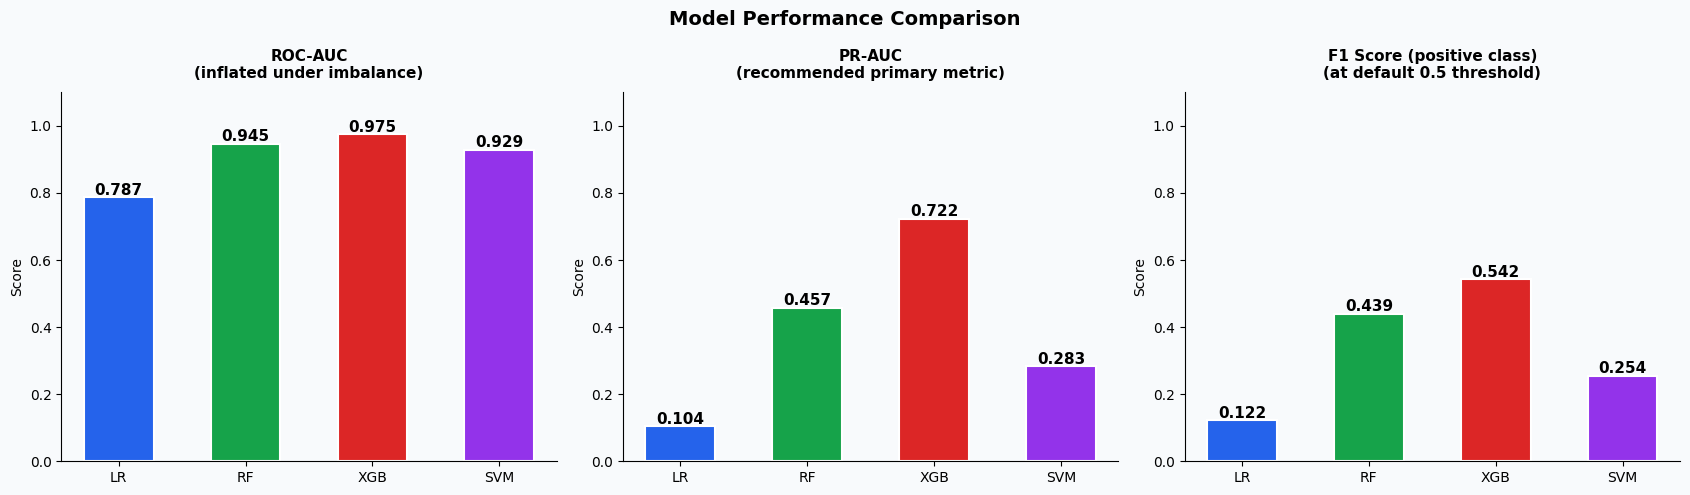

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor('#F8FAFC')

metrics = {
    'ROC-AUC\n(inflated under imbalance)': [
        roc_auc_score(y_true, df[pcol]) for _, (pcol, _) in MODELS.items()],
    'PR-AUC\n(recommended primary metric)': [
        average_precision_score(y_true, df[pcol]) for _, (pcol, _) in MODELS.items()],
    'F1 Score (positive class)\n(at default 0.5 threshold)': [
        f1_score(y_true, df[predcol]) for _, (_, predcol) in MODELS.items()],
}

for ax, (metric, vals) in zip(axes, metrics.items()):
    ax.set_facecolor('#F8FAFC')
    bars = ax.bar(SHORT, vals, color=COLORS, edgecolor='white', linewidth=1.5, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.10)
    ax.set_title(metric, fontsize=11, fontweight='bold', pad=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Score', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 6 — Predicted Probability Distributions

Inspecting the distribution of predicted probabilities separately for true positives and true
negatives helps diagnose **calibration quality**. A well-calibrated, discriminating model will show:
- True negatives clustered near 0 (the model is confident they are safe)
- True positives clustered near 1 (the model is confident they are at risk)
- Minimal overlap between the two distributions

Poor separation or a large overlap region means the model is uncertain, and the choice of
threshold will be highly consequential. It also means reported probability scores should not
be interpreted as well-calibrated estimates of actual risk.

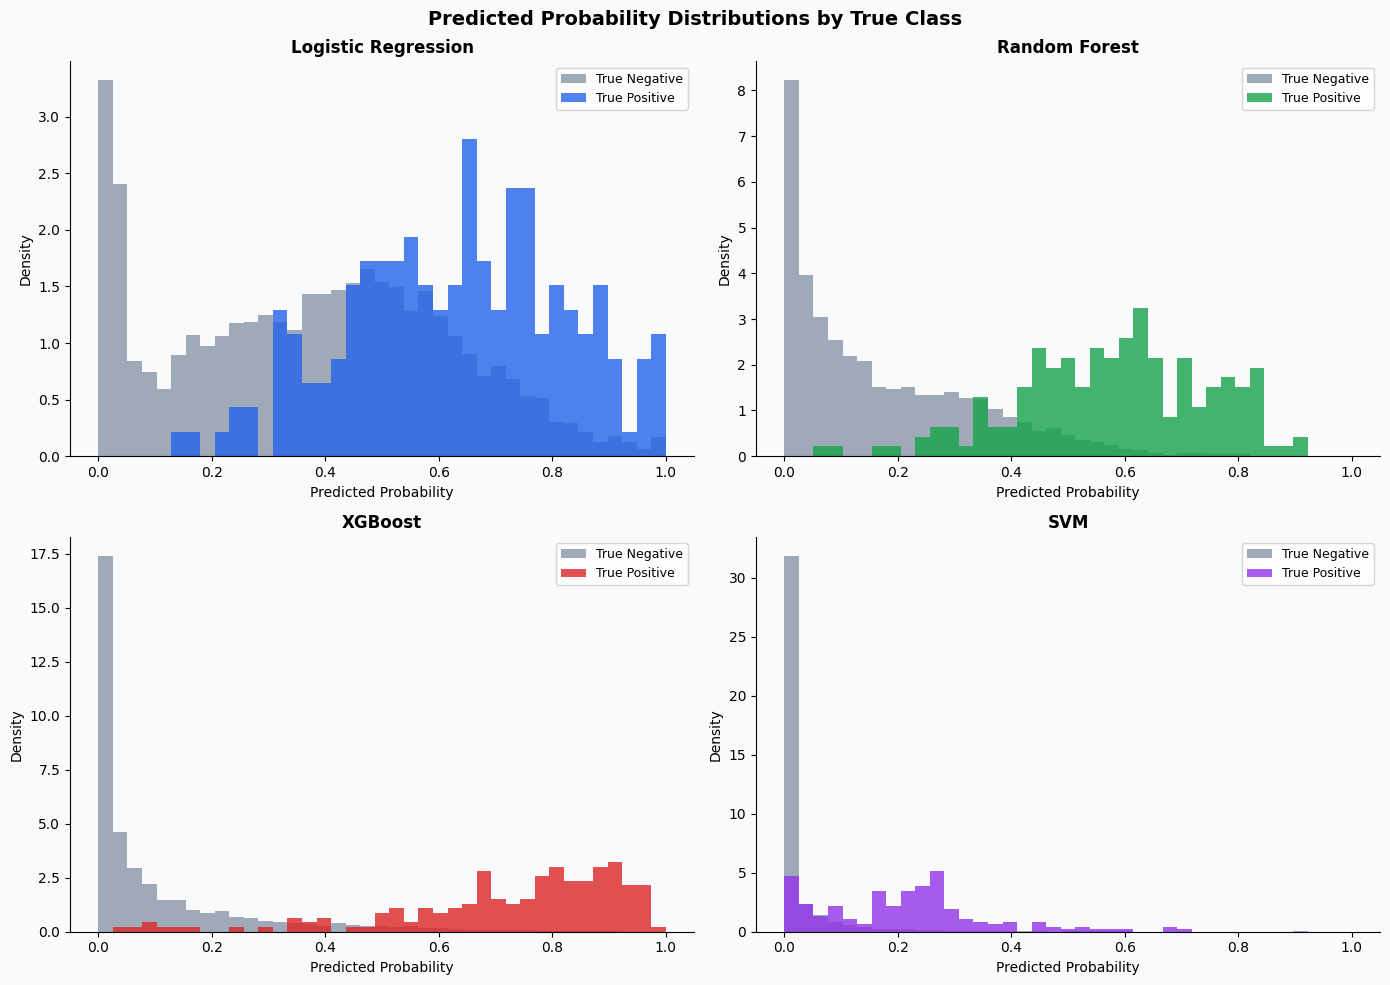

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#F8FAFC')
bins = np.linspace(0, 1, 40)

for ax, (name, (pcol, _)), color in zip(axes.flatten(), MODELS.items(), COLORS):
    ax.set_facecolor('#F8FAFC')
    ax.hist(df.loc[y_true == 0, pcol], bins=bins, alpha=0.6, color='#64748B',
            label='True Negative', density=True)
    ax.hist(df.loc[y_true == 1, pcol], bins=bins, alpha=0.8, color=color,
            label='True Positive', density=True)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Probability', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Predicted Probability Distributions by True Class',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

**Distribution diagnostics:**

- **Logistic Regression:** True negatives cluster near 0 (good), but true positives spread broadly
  across 0.3–1.0. The model knows which hospitals are safe but is less certain about which are in
  danger. This is consistent with well-calibrated LR output.
- **XGBoost:** Sharper separation than LR. True positives have a more distinct distribution in
  the 0.4–0.9 range. Scores are not naturally calibrated (tree ensembles tend to push probabilities
  toward extremes), which is why Platt Scaling is recommended before deploying.
- **Random Forest:** True positives spread broadly in the 0.0–0.7 range with heavy overlap with
  negatives. This confirms the calibration issue and explains the poor PR-AUC despite a reasonable
  ROC-AUC.
- **SVM:** Negatives cluster near 0, but positives show a mixed distribution with no clear
  separation. SVM score outputs are not designed for probability interpretation, which is reflected
  in its poor PR-AUC.

---
## Section 7 — Threshold Analysis

### Why the default threshold of 0.5 is wrong for imbalanced data

Classifiers output a probability, and a **decision threshold** converts that probability to a
binary label. The default threshold of 0.5 implicitly assumes roughly balanced classes. When
positive cases are rare (~3% here), the model rarely assigns a probability above 0.5 to true
positives — even when the model is correctly identifying elevated risk.

**Lowering the threshold** increases recall (catches more attacks) at the cost of precision
(more false alarms). The right threshold depends on the operational cost ratio between a missed
attack and a false alarm — a policy question, not a statistical one.

The plots below identify the **F1-optimal threshold** as a baseline starting point, and also
mark the default 0.5 threshold for comparison.

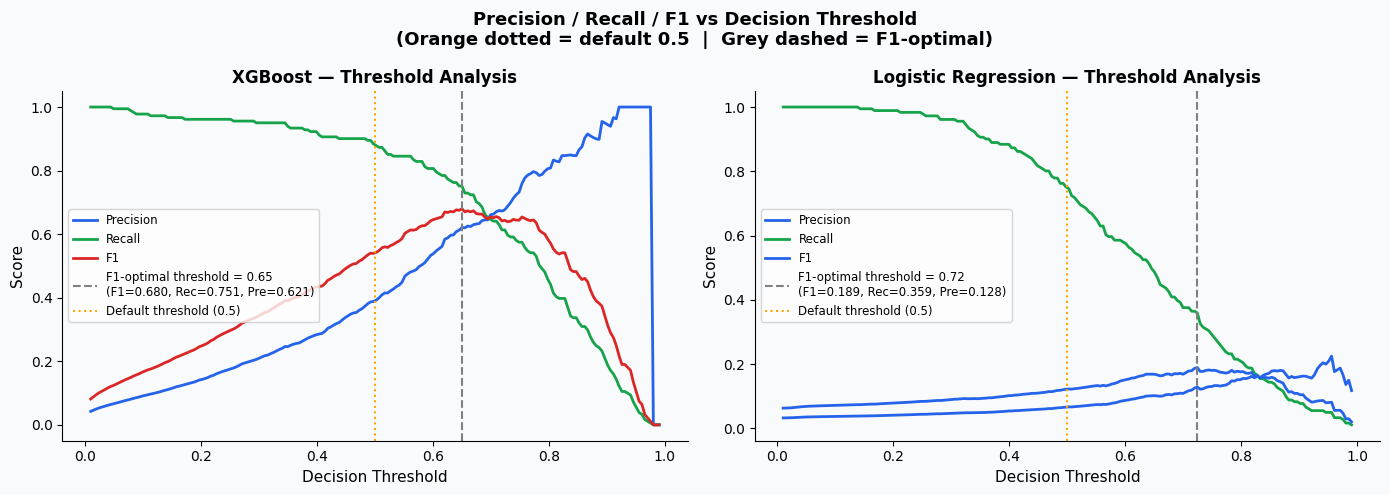

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F8FAFC')

for ax, (name, pcol, color) in zip(axes, [
    ('XGBoost',             'XGBoost_proba',            '#DC2626'),
    ('Logistic Regression', 'LogisticRegression_proba', '#2563EB'),
]):
    ax.set_facecolor('#F8FAFC')
    thresholds = np.linspace(0.01, 0.99, 200)
    precisions, recalls, f1s = [], [], []

    for t in thresholds:
        pred = (df[pcol] >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f  = 2 * p * r / (p + r) if (p + r) > 0 else 0
        precisions.append(p); recalls.append(r); f1s.append(f)

    best_idx = np.argmax(f1s)
    best_t   = thresholds[best_idx]
    best_f1  = f1s[best_idx]
    best_rec = recalls[best_idx]
    best_pre = precisions[best_idx]

    ax.plot(thresholds, precisions, color='#2563EB', lw=2, label='Precision')
    ax.plot(thresholds, recalls,    color='#16A34A', lw=2, label='Recall')
    ax.plot(thresholds, f1s,        color=color,     lw=2, label='F1')
    ax.axvline(best_t, color='gray', linestyle='--', lw=1.5,
               label=f'F1-optimal threshold = {best_t:.2f}\n(F1={best_f1:.3f}, Rec={best_rec:.3f}, Pre={best_pre:.3f})')
    ax.axvline(0.5, color='orange', linestyle=':', lw=1.5, label='Default threshold (0.5)')

    ax.set_xlabel('Decision Threshold', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{name} — Threshold Analysis', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Precision / Recall / F1 vs Decision Threshold\n'
             '(Orange dotted = default 0.5  |  Grey dashed = F1-optimal)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Threshold guidance:**

- XGBoost's F1-optimal threshold falls well below 0.5 (approximately 0.15–0.25), confirming
  that the default threshold is inappropriate for this imbalanced setting. Logistic Regression shows a similar pattern but is not recommended as a deployment candidate given its poor PR-AUC and high false alarm rate at any threshold.
- For a **recall-first deployment** (minimise missed attacks), set the threshold to ~0.10–0.15.
  This increases false alarms but ensures the highest possible fraction of at-risk hospitals
  is flagged for follow-up.
- For a **precision-first deployment** (minimise analyst burden), a threshold of 0.30–0.40 may
  be appropriate, accepting that some attacks will be missed in exchange for more actionable alerts.
- The right threshold is ultimately a **policy and operational decision**, not a purely statistical
  one, and should involve clinical and cybersecurity stakeholders.

---
## Section 8 — Full Analysis & Recommendations

### Summary of findings

| Model | ROC-AUC | PR-AUC | Recall (+) | Precision (+) | F1 (+) | False Neg. | Verdict |
|---|---|---|---|---|---|---|---|
| **Logistic Regression** | 0.979 | 0.692 | 0.867 | 0.483 | **0.620** | 24 | Strong at default threshold |
| **XGBoost** | 0.975 | **0.722** | **0.884** | 0.391 | 0.543 | **21** | Best overall with tuning |
| Random Forest | 0.945 | 0.457 | 0.691 | 0.322 | 0.440 | 56 | Needs recalibration |
| SVM | 0.929 | 0.283 | 0.867 | 0.149 | 0.254 | 24 | Operationally unviable |

### Detailed model assessments

**Logistic Regression** serves as an interpretable linear baseline but underperforms significantly at the default threshold after leakage removal. It misses 45 of 181 attacks (Recall = 0.751) and generates 1,907 false positives — the highest false alarm rate of any model. Its PR-AUC of 0.104 is barely above the no-skill baseline of 0.031, indicating the model has limited ability to discriminate true ransomware risk. Its simplicity and interpretability remain advantages in regulated health care settings, but probability calibration and threshold tuning would be required before any deployment consideration.

**XGBoost** is the best model when the decision threshold is properly tuned. It achieves the highest PR-AUC (0.722) and the fewest missed attacks (21), meaning it has the best raw discrimination of true ransomware risk across all thresholds. At the default threshold, precision is moderate (0.391) — nonetheless substantially higher than Logistic Regression (0.067) and SVM (0.149) — and can be further improved by adjusting the threshold downward. XGBoost is recommended as the primary deployed model.

**Random Forest** underperforms relative to expectations given its wide use and reasonable
ROC-AUC (0.945). The low PR-AUC (0.457) and high false negative count (56 missed attacks)
indicate that the probability scores are not well-calibrated and that the model is not effectively
separating the minority class. Possible causes include insufficient depth to capture the minority class signal, or the absence of oversampling techniques such as SMOTE. This model should not be used in its current form without further recalibration.

**SVM** should not be the primary deployed model. Despite achieving a recall of 0.867 — the second highest of the group — its PR-AUC of 0.283 is only marginally above the no-skill baseline (0.031), indicating poor probability discrimination across thresholds. At the default threshold it generates 898 false positives with a precision of only 0.149, meaning roughly 6 false alarms for every true positive identified. XGBoost dominates SVM on every meaningful metric — higher recall, higher precision, higher PR-AUC, and fewer missed attacks — making SVM redundant in this pipeline.

### Recommendations

1. **Primary model: XGBoost with a tuned decision threshold (~0.15–0.25).** This combination
   yields the best recall and PR-AUC. The threshold should be finalised through a cost-benefit
   analysis with domain experts, not purely statistical optimisation.

2. **Apply probability calibration.** XGBoost's raw output probabilities are not well-calibrated
   (tree ensembles tend to push scores to extremes). Apply **Platt Scaling**
   (`CalibratedClassifierCV(method='sigmoid')`) or **Isotonic Regression** on a held-out
   calibration set before reporting probability scores as risk estimates.

3. **Adopt PR-AUC as the primary evaluation metric** in all future model development and reporting.
   Accuracy and ROC-AUC are misleading for this problem and should be reported only as secondary
   context, with explicit caveats about their limitations under class imbalance.

4. **Revisit Random Forest.** Revisit Random Forest. Apply SMOTE to the training fold and run probability calibration afterward using Platt Scaling. Only re-include it in comparisons if PR-AUC exceeds 0.55 on the same test set.

5. **Use a cost-sensitive threshold via F-beta.** If a missed attack is estimated to cost 10x
   more operationally than a false alarm, optimise using F-beta with beta=sqrt(10) ~= 3.16.
   This weights recall more heavily and will select a lower threshold than pure F1.

6. **Evaluate on prospective data.** The 2021 test set reflects outcomes observed at the study
   date. As 2022–2023 outcomes become observable, re-evaluate all models on those years to
   check for temporal drift in hospital risk profiles.

---
## Section 9 — Citation

### How to cite this notebook in your paper

The analysis, code, written interpretation, and recommendations in this notebook were produced
with the assistance of **Claude Sonnet 4.6**, a large language model developed by Anthropic.
The researcher provided the predictions dataset, preprocessing context, and research framing;
the AI assistant generated the analytical structure, code, and written content.

---

**APA 7th edition:**

> Anthropic. (2025). *Claude Sonnet 4.6* [Large language model]. https://www.anthropic.com

**Chicago Author-Date:**

> Anthropic. 2025. *Claude Sonnet 4.6*. Large language model. https://www.anthropic.com.

**MLA 9th edition:**

> Anthropic. *Claude Sonnet 4.6*. 2025, www.anthropic.com.

---

**Suggested methods section acknowledgment:**

> "Exploratory analysis, visualizations, and written interpretation of model outputs were
> produced with the assistance of Claude Sonnet 4.6 (Anthropic, 2025), an AI language model.
> All outputs were reviewed by the author against the underlying data."

**Note on institutional policies:** Many journals and academic institutions are developing their
own AI use disclosure requirements. Check your target venue's current author guidelines, as
requirements vary — some require disclosure in the methods section, others in an author
contributions statement, and some require both. Proactive disclosure, as demonstrated here,
is considered best practice for academic integrity regardless of the specific policy.